In [ ]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
from endgame import hist2d
from eod import msg
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from utils import u_stats
from COCOON import shear_scaling_plots
importlib.reload(shear_scaling_plots)
from LMCS import glob_util

%matplotlib inline

In [1]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [16]:
REGIONS = glob_util.REGIONS
style = glob_util.REGION_STYLE

In [4]:
style.keys()

dict_keys(['WAf', 'CAf', 'EAf', 'india', 'trop_SA', 'GPlains', 'Eur', 'china', 'sub_SA', 'SAf', 'Atl', 'Pcf', 'InO', 'australia'])

In [5]:
TABLE_PATH = '/prj/global_water/MCS_5000km2_tables_v3/base_tables_tir-prcp/'
dics = {}

for reg in REGIONS.keys():

    dfs = []

    for y in range(2000, 2021):

        files = glob.glob(
            f"{TABLE_PATH}/{reg}/{y}*.parquet"
        )

        if len(files) == 0:
            #print(reg, y, "not found")
            continue

        #print("Reading", files[0])

        df = pd.read_parquet(files[0])

        dfs.append(df)

    if len(dfs) == 0:
        #print(reg, "has no files")
        continue

    dics[reg] = pd.concat(dfs, ignore_index=True)

    print(reg, len(dics[reg]))

GPlains 253494
Eur 271371
china 308143
india 984179
WAf 1256238
australia 284903
SAf 358974
sub_SA 396609
trop_SA 2081609
CAf 1050754
EAf 579377
Atl 729065
Pcf 893353
InO 1046309


In [6]:
print(list(dics['WAf'].keys()))

['date', 'month', 'hour', 'minute', 'year', 'day', 'area', 'area70', 'area60', 'area50', 'minlon', 'minlat', 'maxlon', 'maxlat', 'clon', 'clat', 'tminlon', 'tminlat', 'tmin', 'tmean', 'tp1', 'tp99', 'stormID', 'shape_complexity', 'major_axis_km', 'minor_axis_km', 'aspect_ratio', 'precipitation_mean', 'precipitation_max', 'precipitation_p80', 'precipitation_p90', 'precipitation_p95', 'precipitation_p99', 'precipitation_area1mm', 'precipitation_area3mm', 'precipitation_area8mm', 'region']


In [7]:
print(list(np.unique(dics['india']['hour'])))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


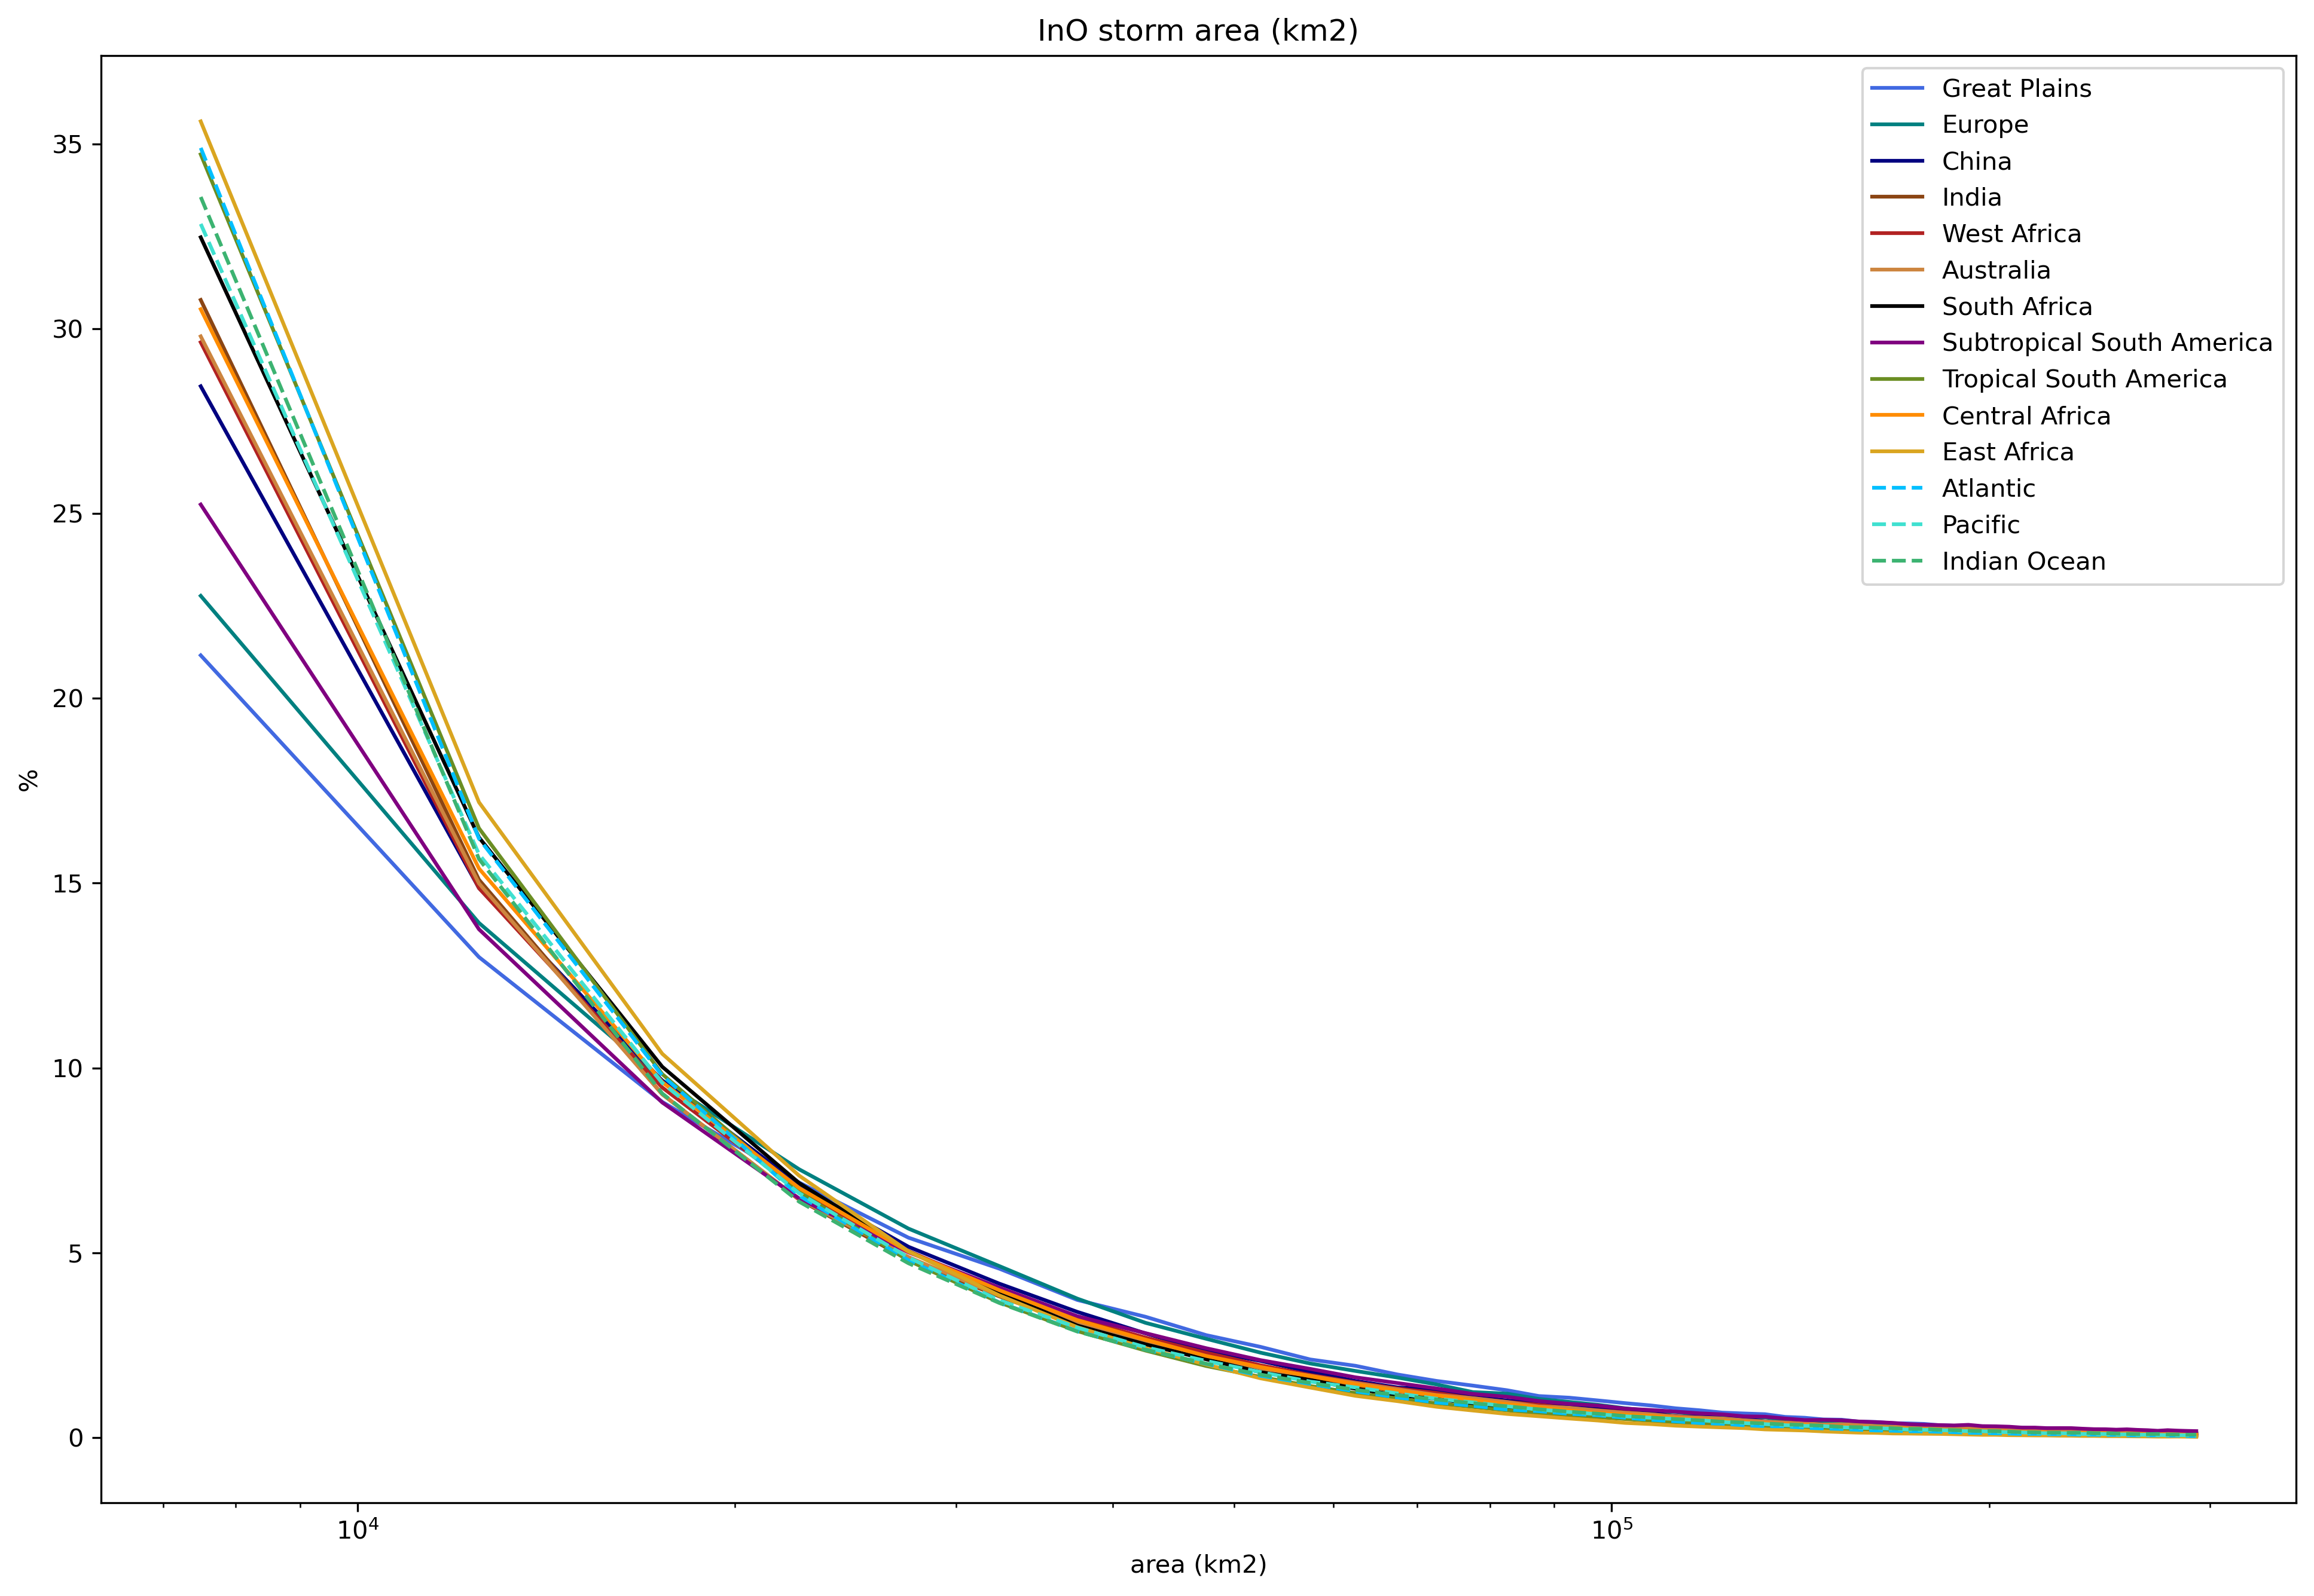

In [17]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['area'], bins=np.arange(5000,300000,5000))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])

plt.legend()
ax.set_title(regs+' storm area (km2)')
plt.xscale('log')
plt.ylabel('%')
plt.xlabel('area (km2)')

plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/trackVSsnapshot/australia_trackVSsnapshot_area_histo.jpg')

In [10]:
np.sum(hist_freq)

np.float64(99.92191599223246)

GPlains 1.0000245571136475
Eur 1.0
china 1.0000722408294678
india 1.0
WAf 1.000000238418579
australia 1.0
SAf 1.0000033378601074
sub_SA 1.0000027418136597
trop_SA 1.0000196695327759
CAf 1.0000003576278687
EAf 1.0000745058059692
Atl 1.0
Pcf 1.0
InO 1.0


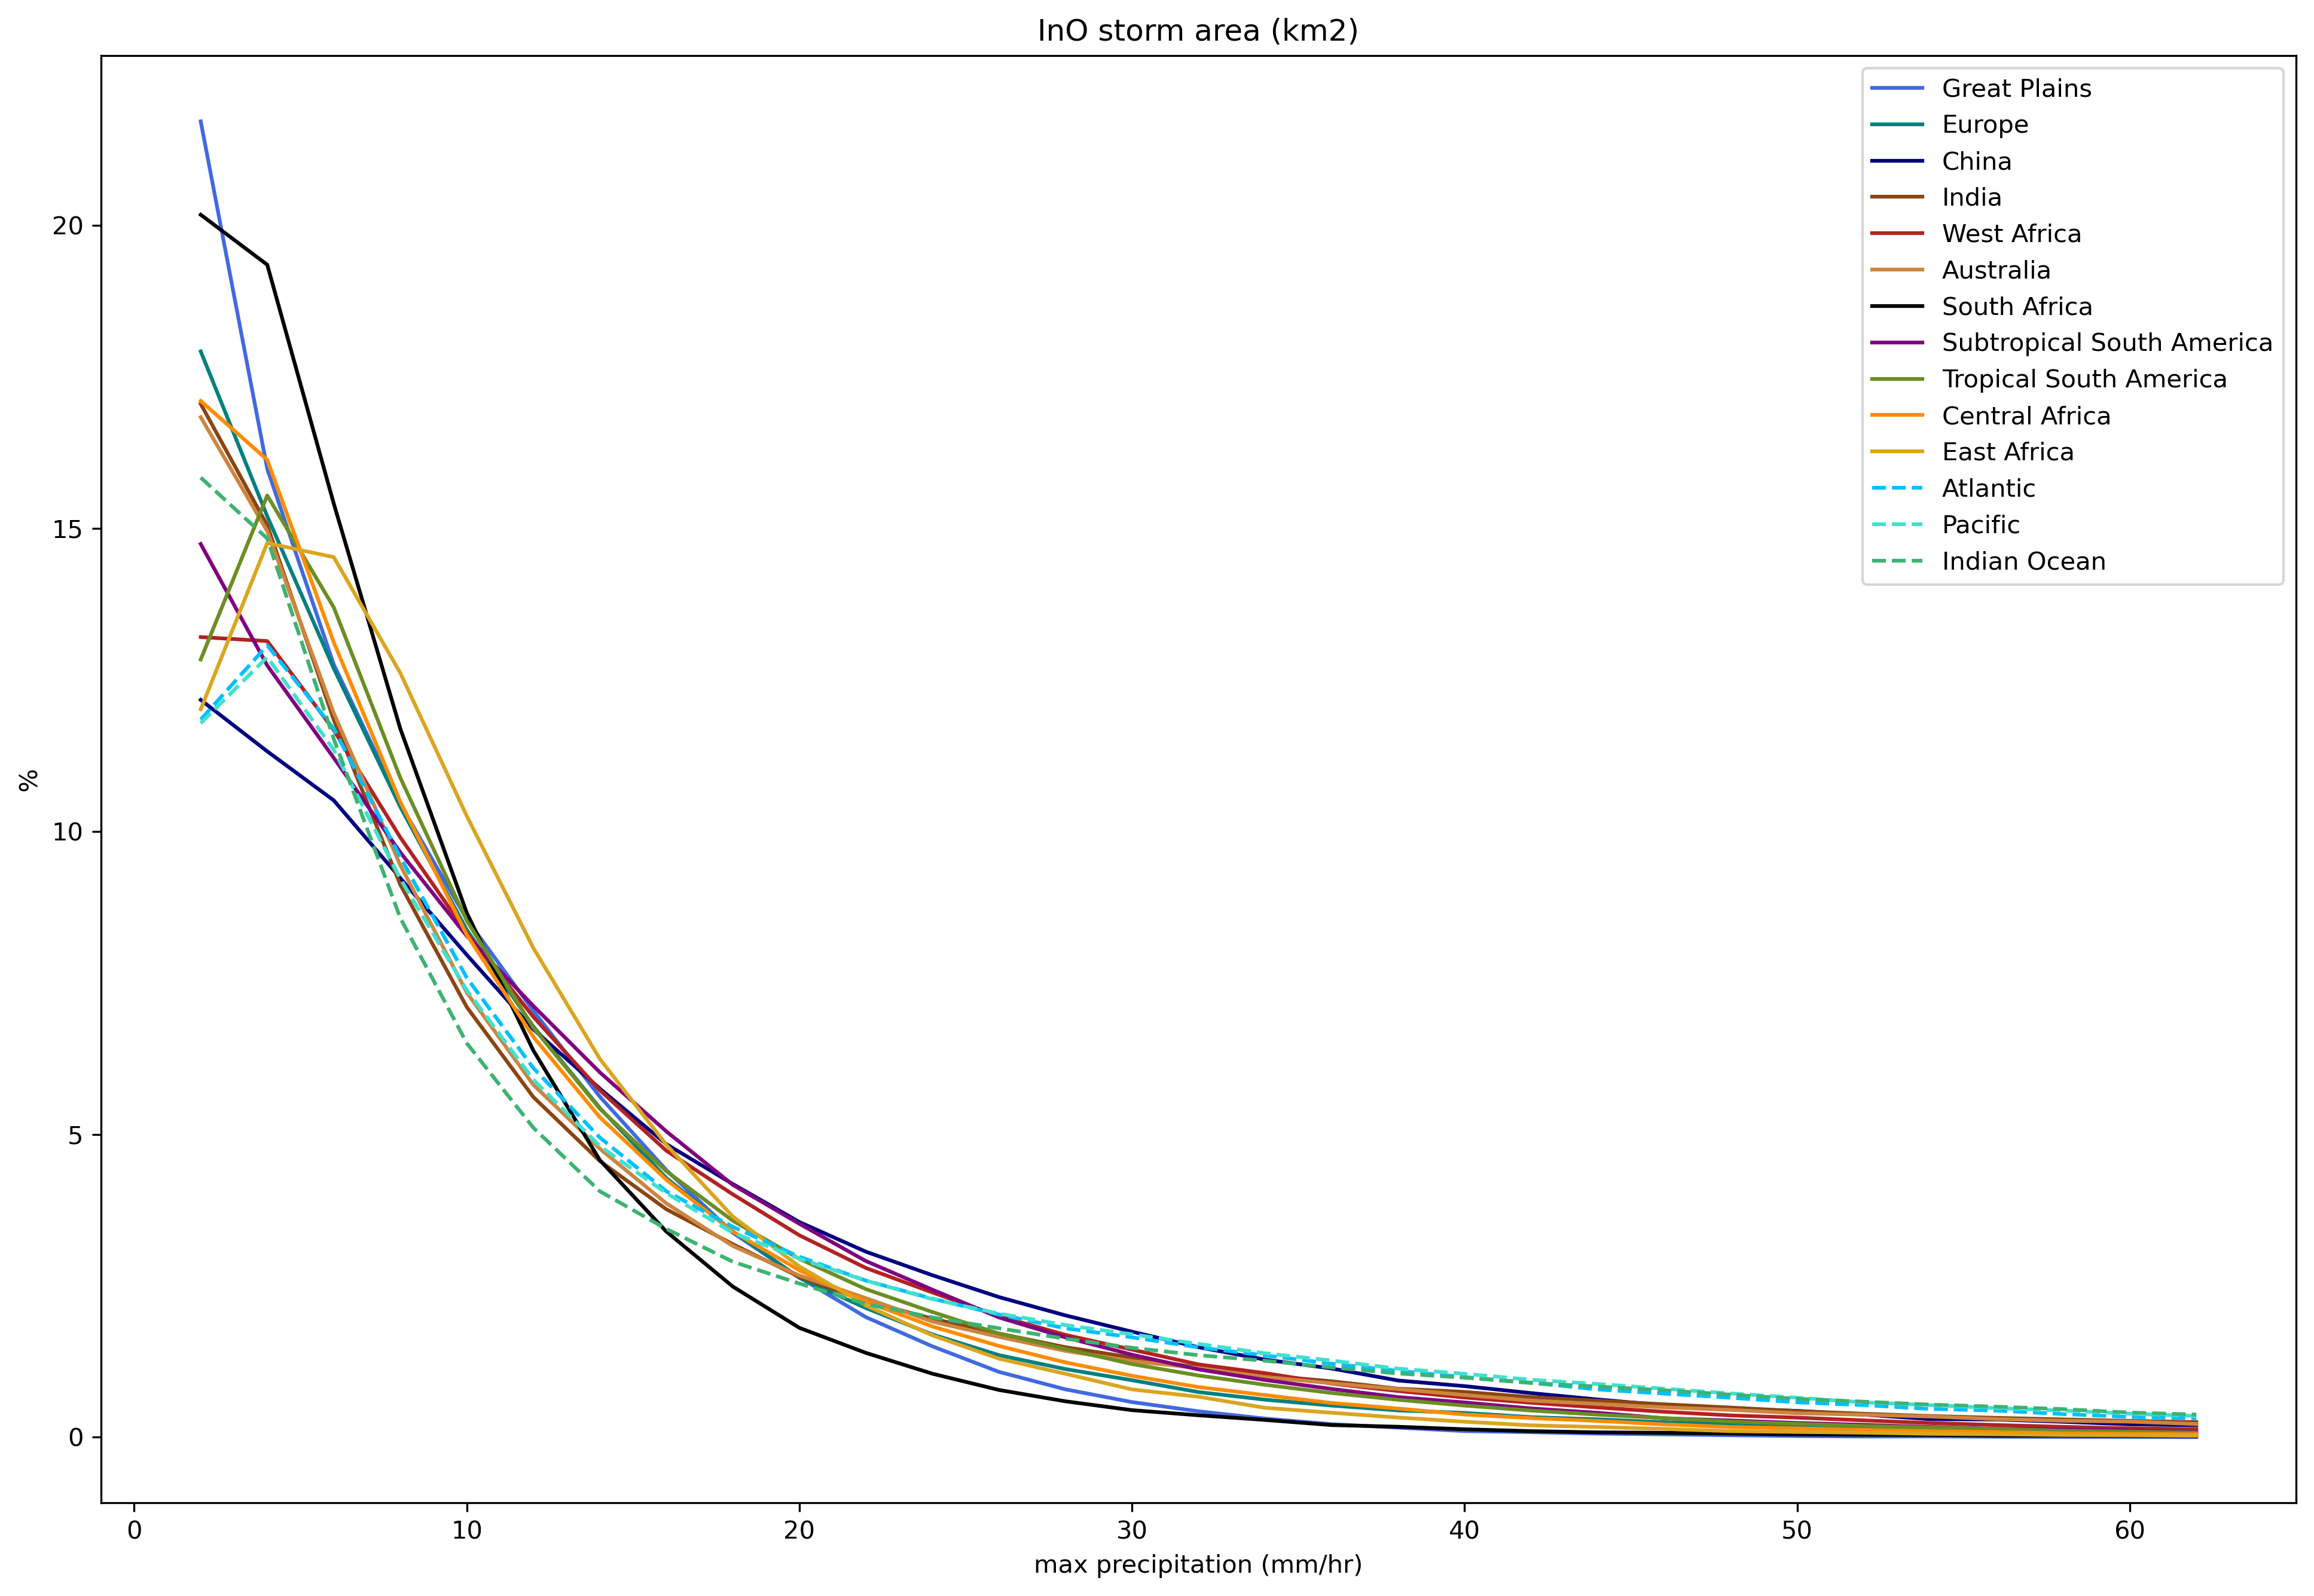

In [18]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_max'], bins=np.arange(1,65,2))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])

    print(regs,pick['precipitation_max'].min())

plt.legend()
ax.set_title(regs+' storm area (km2)')
#plt.xscale('log')
plt.ylabel('%')
plt.xlabel('max precipitation (mm/hr)')

plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/trackVSsnapshot/australia_trackVSsnapshot_area_histo.jpg')

/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492

GPlains -82.11373901367188
Eur -74.13250732421875
china -94.14999389648438
india -112.93296813964844
WAf -113.14222717285156
australia -96.57717895507812
SAf -111.09426879882812
sub_SA -111.30570983886719


/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/tmp/ipykernel_2396492

trop_SA -112.5899658203125
CAf -112.82720947265625
EAf -99.14999389648438
Atl -94.77215576171875
Pcf -92.14999389648438


/tmp/ipykernel_2396492/1075488293.py:18: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])


InO -109.38018798828125


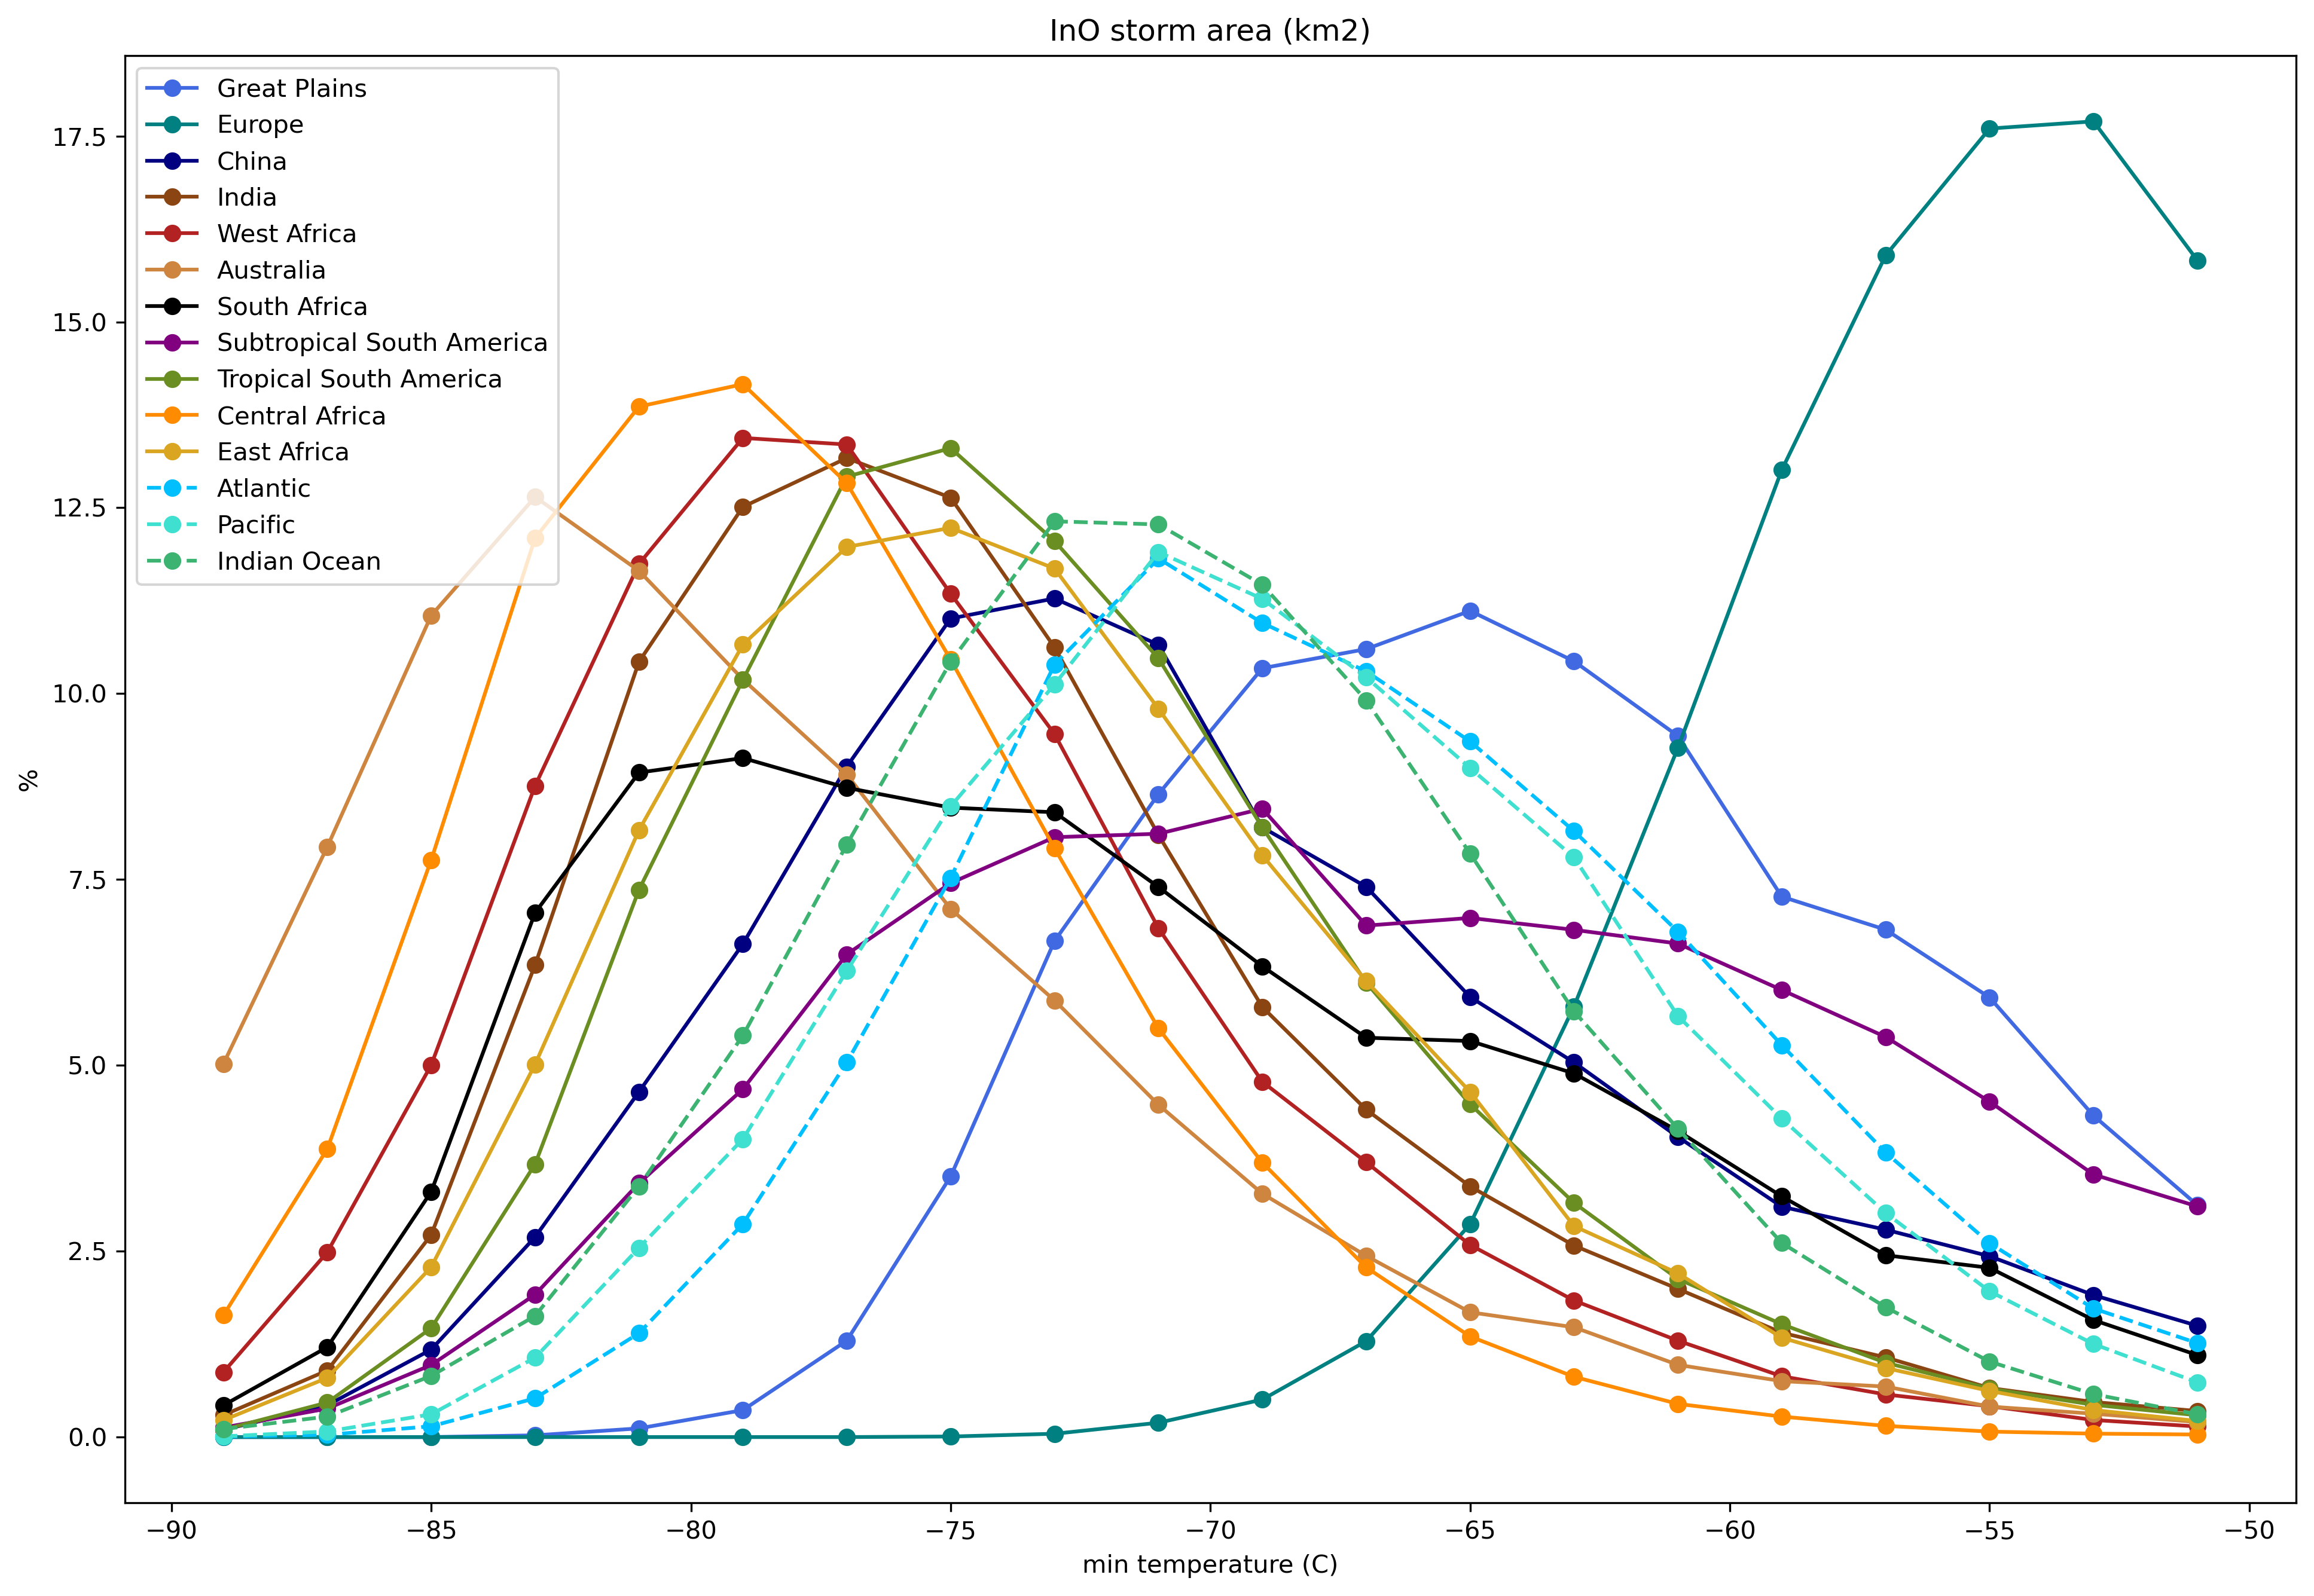

In [28]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    utc_offset = REGIONS[regs][2]
    
    lt_hour = (pick["hour"] + utc_offset) % 24

    pick = pick[
        (lt_hour >= 15) &
        (lt_hour <= 21) & (pick['precipitation_max']>20)
    ]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['tmin'], bins=np.arange(-90,-49,2))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])

    print(regs,pick['tmin'].min())

plt.legend()
ax.set_title(regs+' storm area (km2)')
#plt.xscale('log')
plt.ylabel('%')
plt.xlabel('min temperature (C)')

plt.tight_layout()

/users/global/cornkle/pythonWorkspace/proj_CEH/endgame/hist2d.py:412: RuntimeWarning: invalid value encountered in divide
  outdic['y'].append(np.sum(yvar[mask]>gt)/float(np.sum(np.isfinite(yvar[mask]))))
/tmp/ipykernel_2396492/2761720624.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(outdic['xbins'], outdic['y'], '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
/users/global/cornkle/pythonWorkspace/proj_CEH/endgame/hist2d.py:412: RuntimeWarning: invalid value encountered in divide
  outdic['y'].append(np.sum(yvar[mask]>gt)/float(np.sum(np.isfinite(yvar[mask]))))
/tmp/ipykernel_2396492/2761720624.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(outdic['xbins'], outdic['y'], '

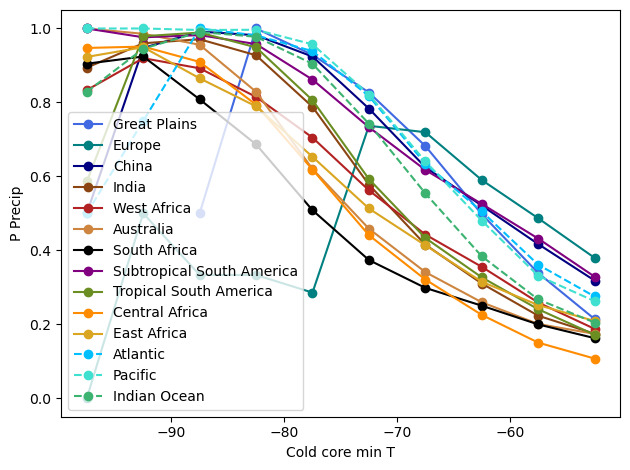

In [37]:
ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    utc_offset = REGIONS[regs][2]
    
    lt_hour = (pick["hour"] + utc_offset) % 24

    pick = pick[ (pick['precipitation_max']>2)
    ]

    outdic = hist2d.var2_binning_threshold((pick['tmin']).values, (pick['precipitation_max']).values, np.arange(-100,-40,5), gt=10)
    plt.plot(outdic['xbins'], outdic['y'], '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])

   
    ax.set_ylim(0,1)
plt.ylabel('P Precip')
plt.xlabel('Cold core min T')
plt.legend()
plt.tight_layout()

/tmp/ipykernel_2396492/2057801909.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(np.arange(0,1,0.1), hist, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])


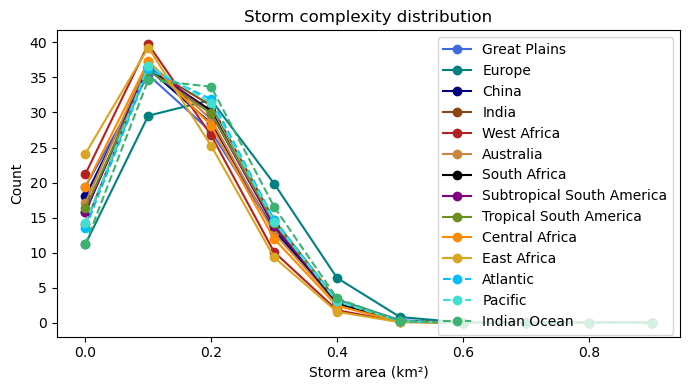

In [40]:
bins = np.linspace(0,1.1,11)

plt.figure(figsize=(7,4))
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    utc_offset = REGIONS[regs][2]


    hist, count, hbins = u_stats.histo_frequency(pick['shape_complexity'], bins=bins)

    #ipdb.set_trace()
    xbins = hbins[0:-1] + (hbins[1::]-hbins[0:-1])/2

    plt.plot(np.arange(0,1,0.1), hist, '-o', c=style[regs]['color'], linestyle=style[regs]['ls'], label=style[regs]['label'])
    
plt.legend()

plt.xlabel("Storm area (km²)")
plt.ylabel("Count")
plt.title("Storm complexity distribution")
plt.tight_layout()
plt.show()

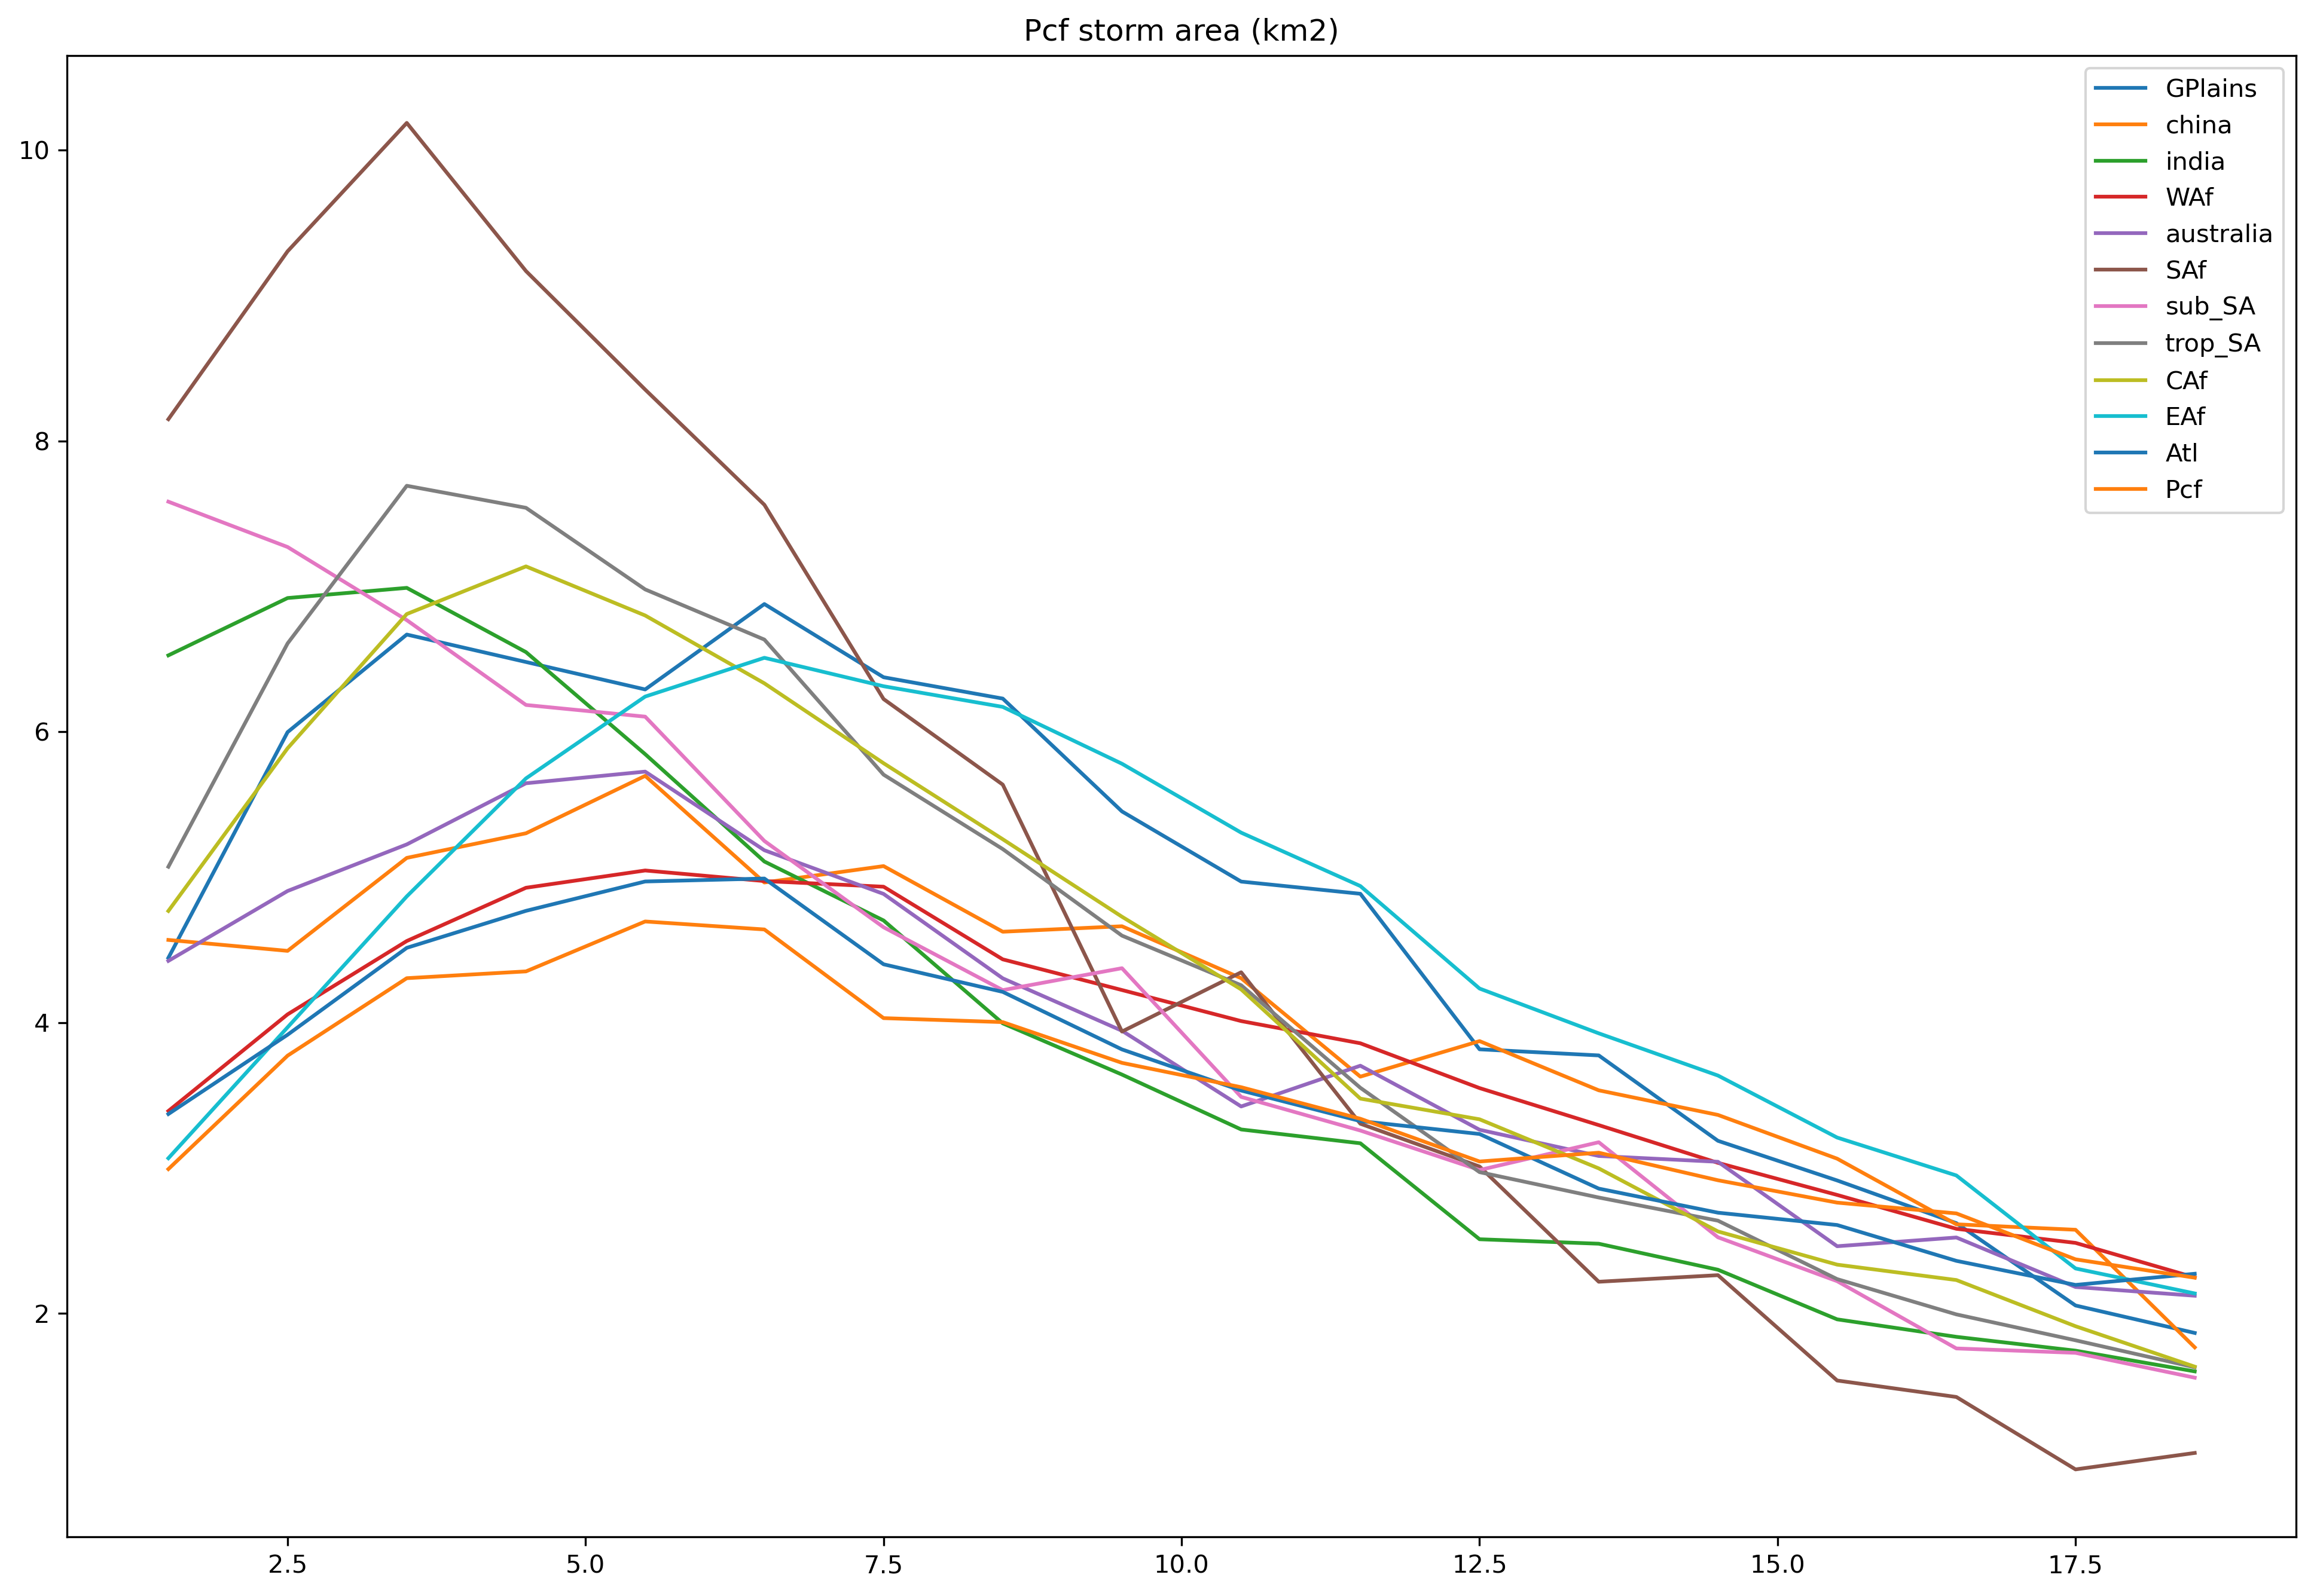

In [62]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.5]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_max'], bins=np.arange(1,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

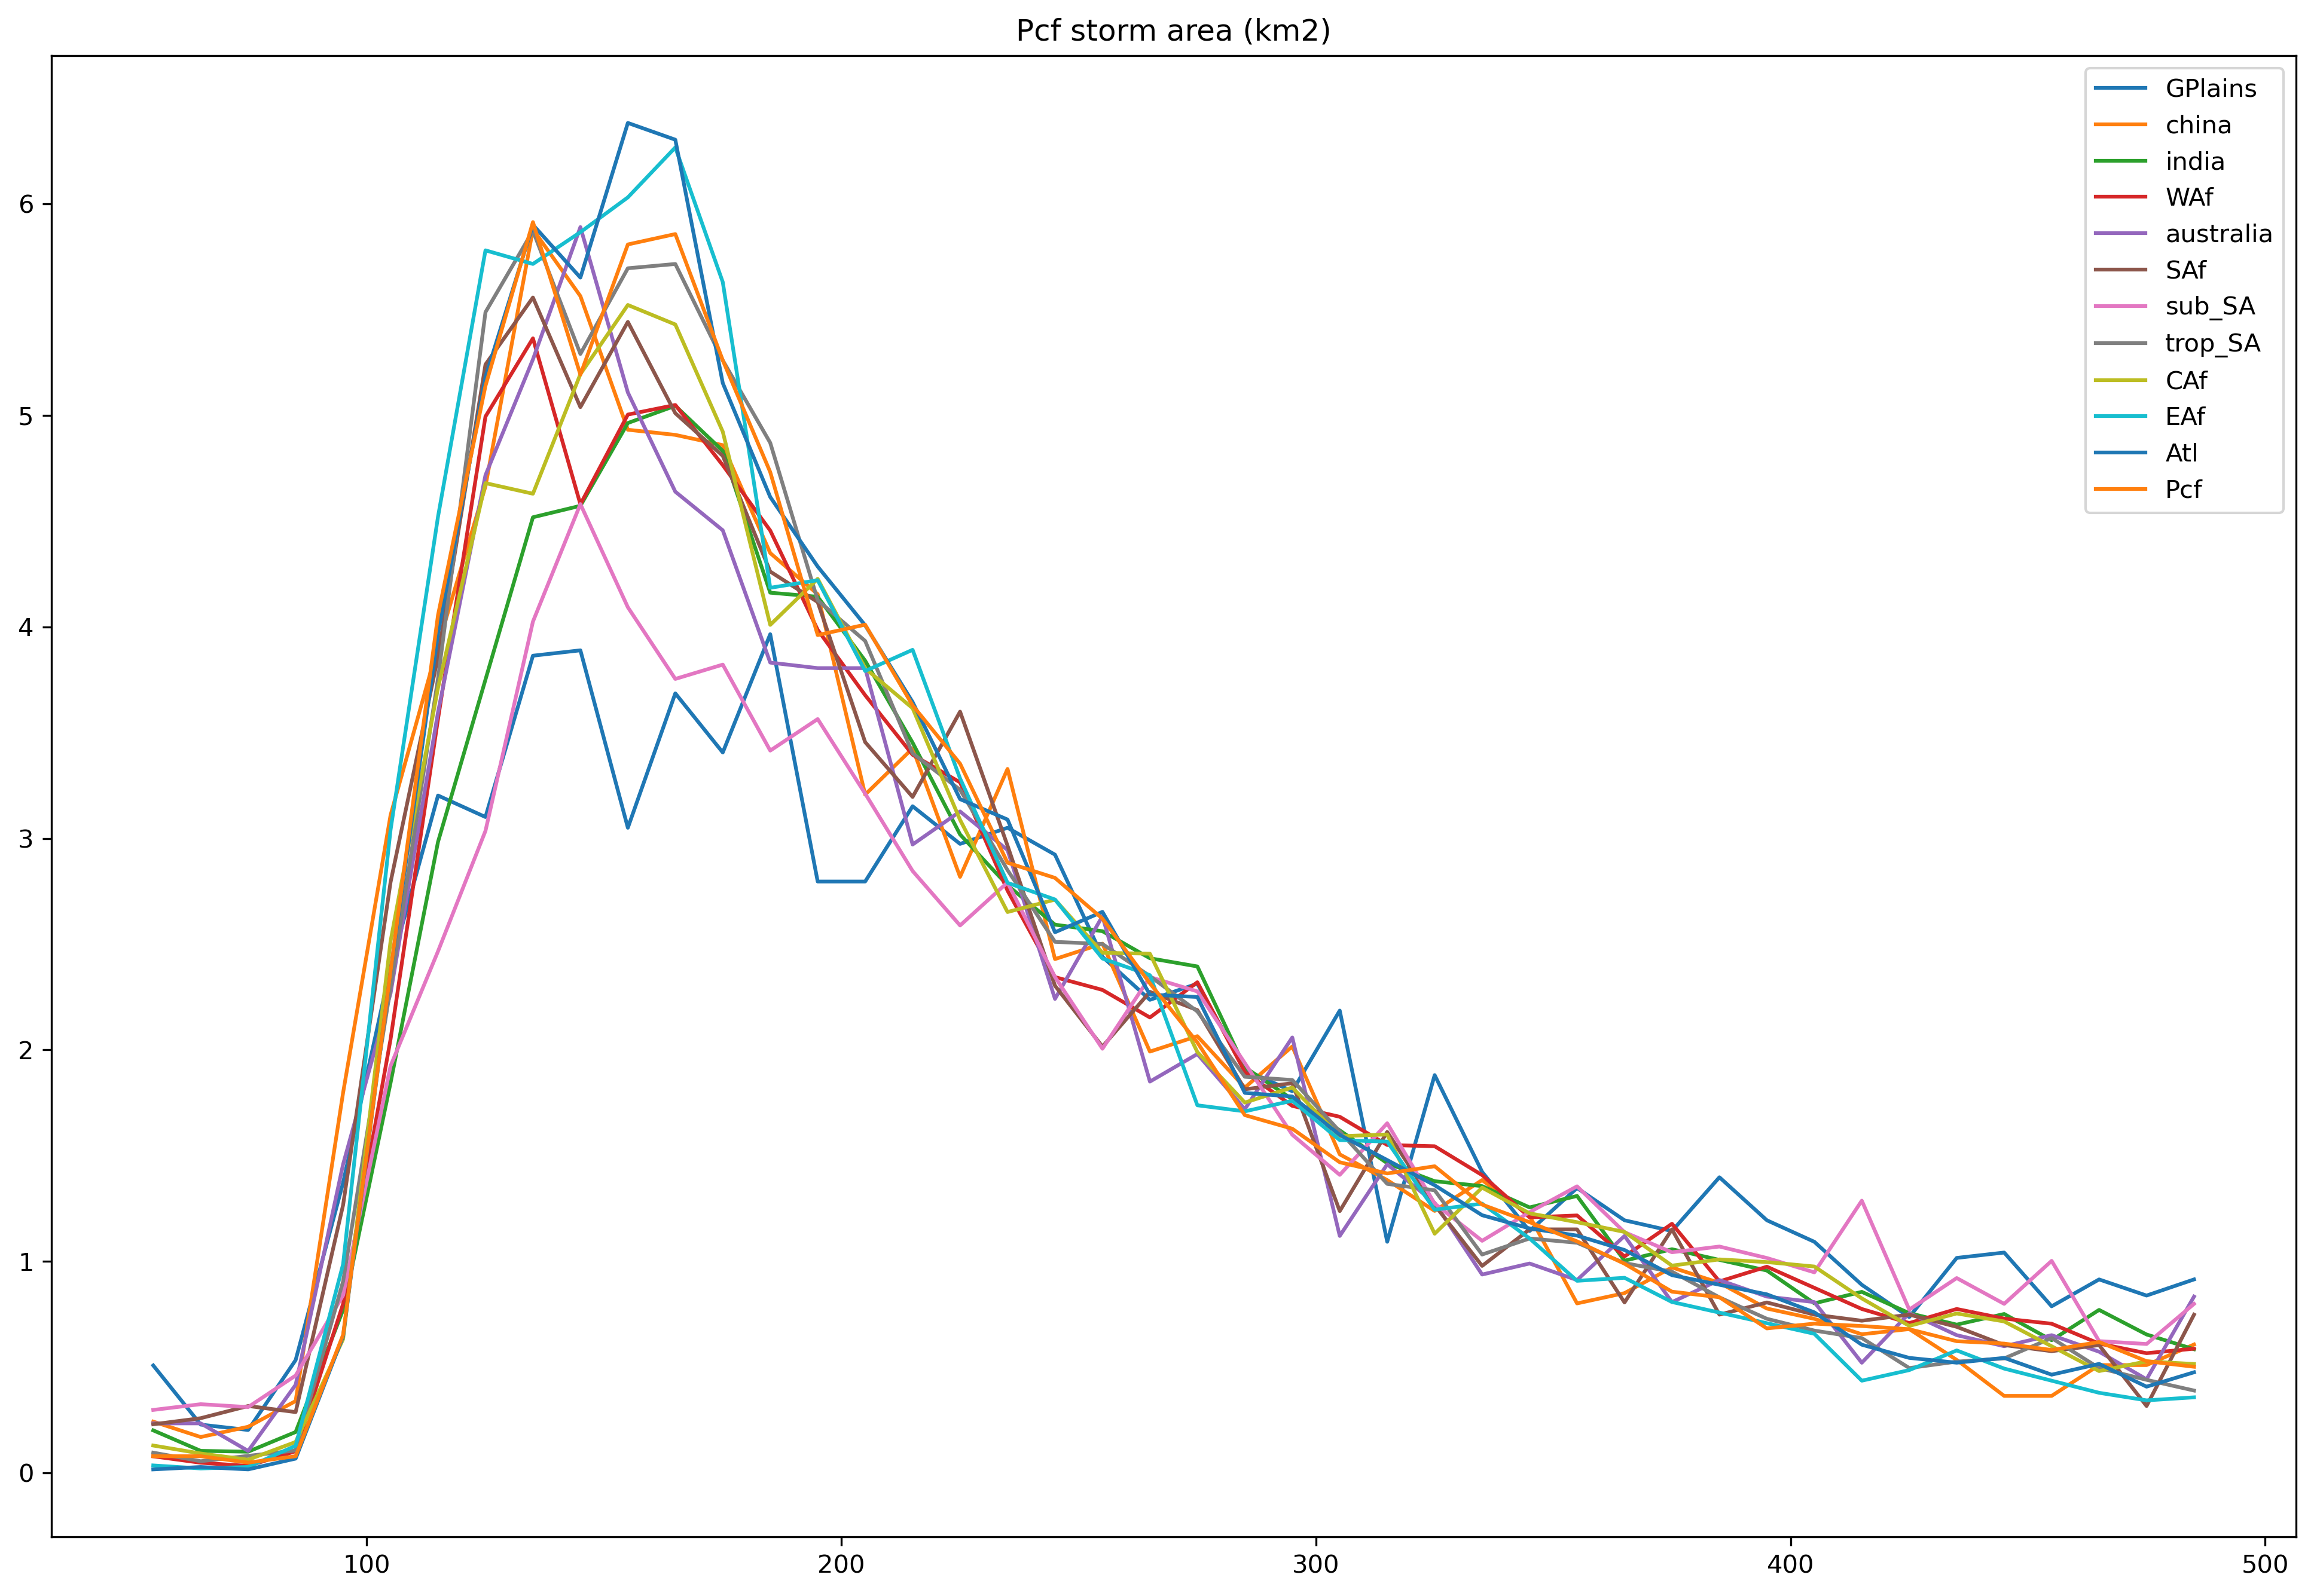

In [66]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.3]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['major_axis_km'], bins=np.arange(50,500,10))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

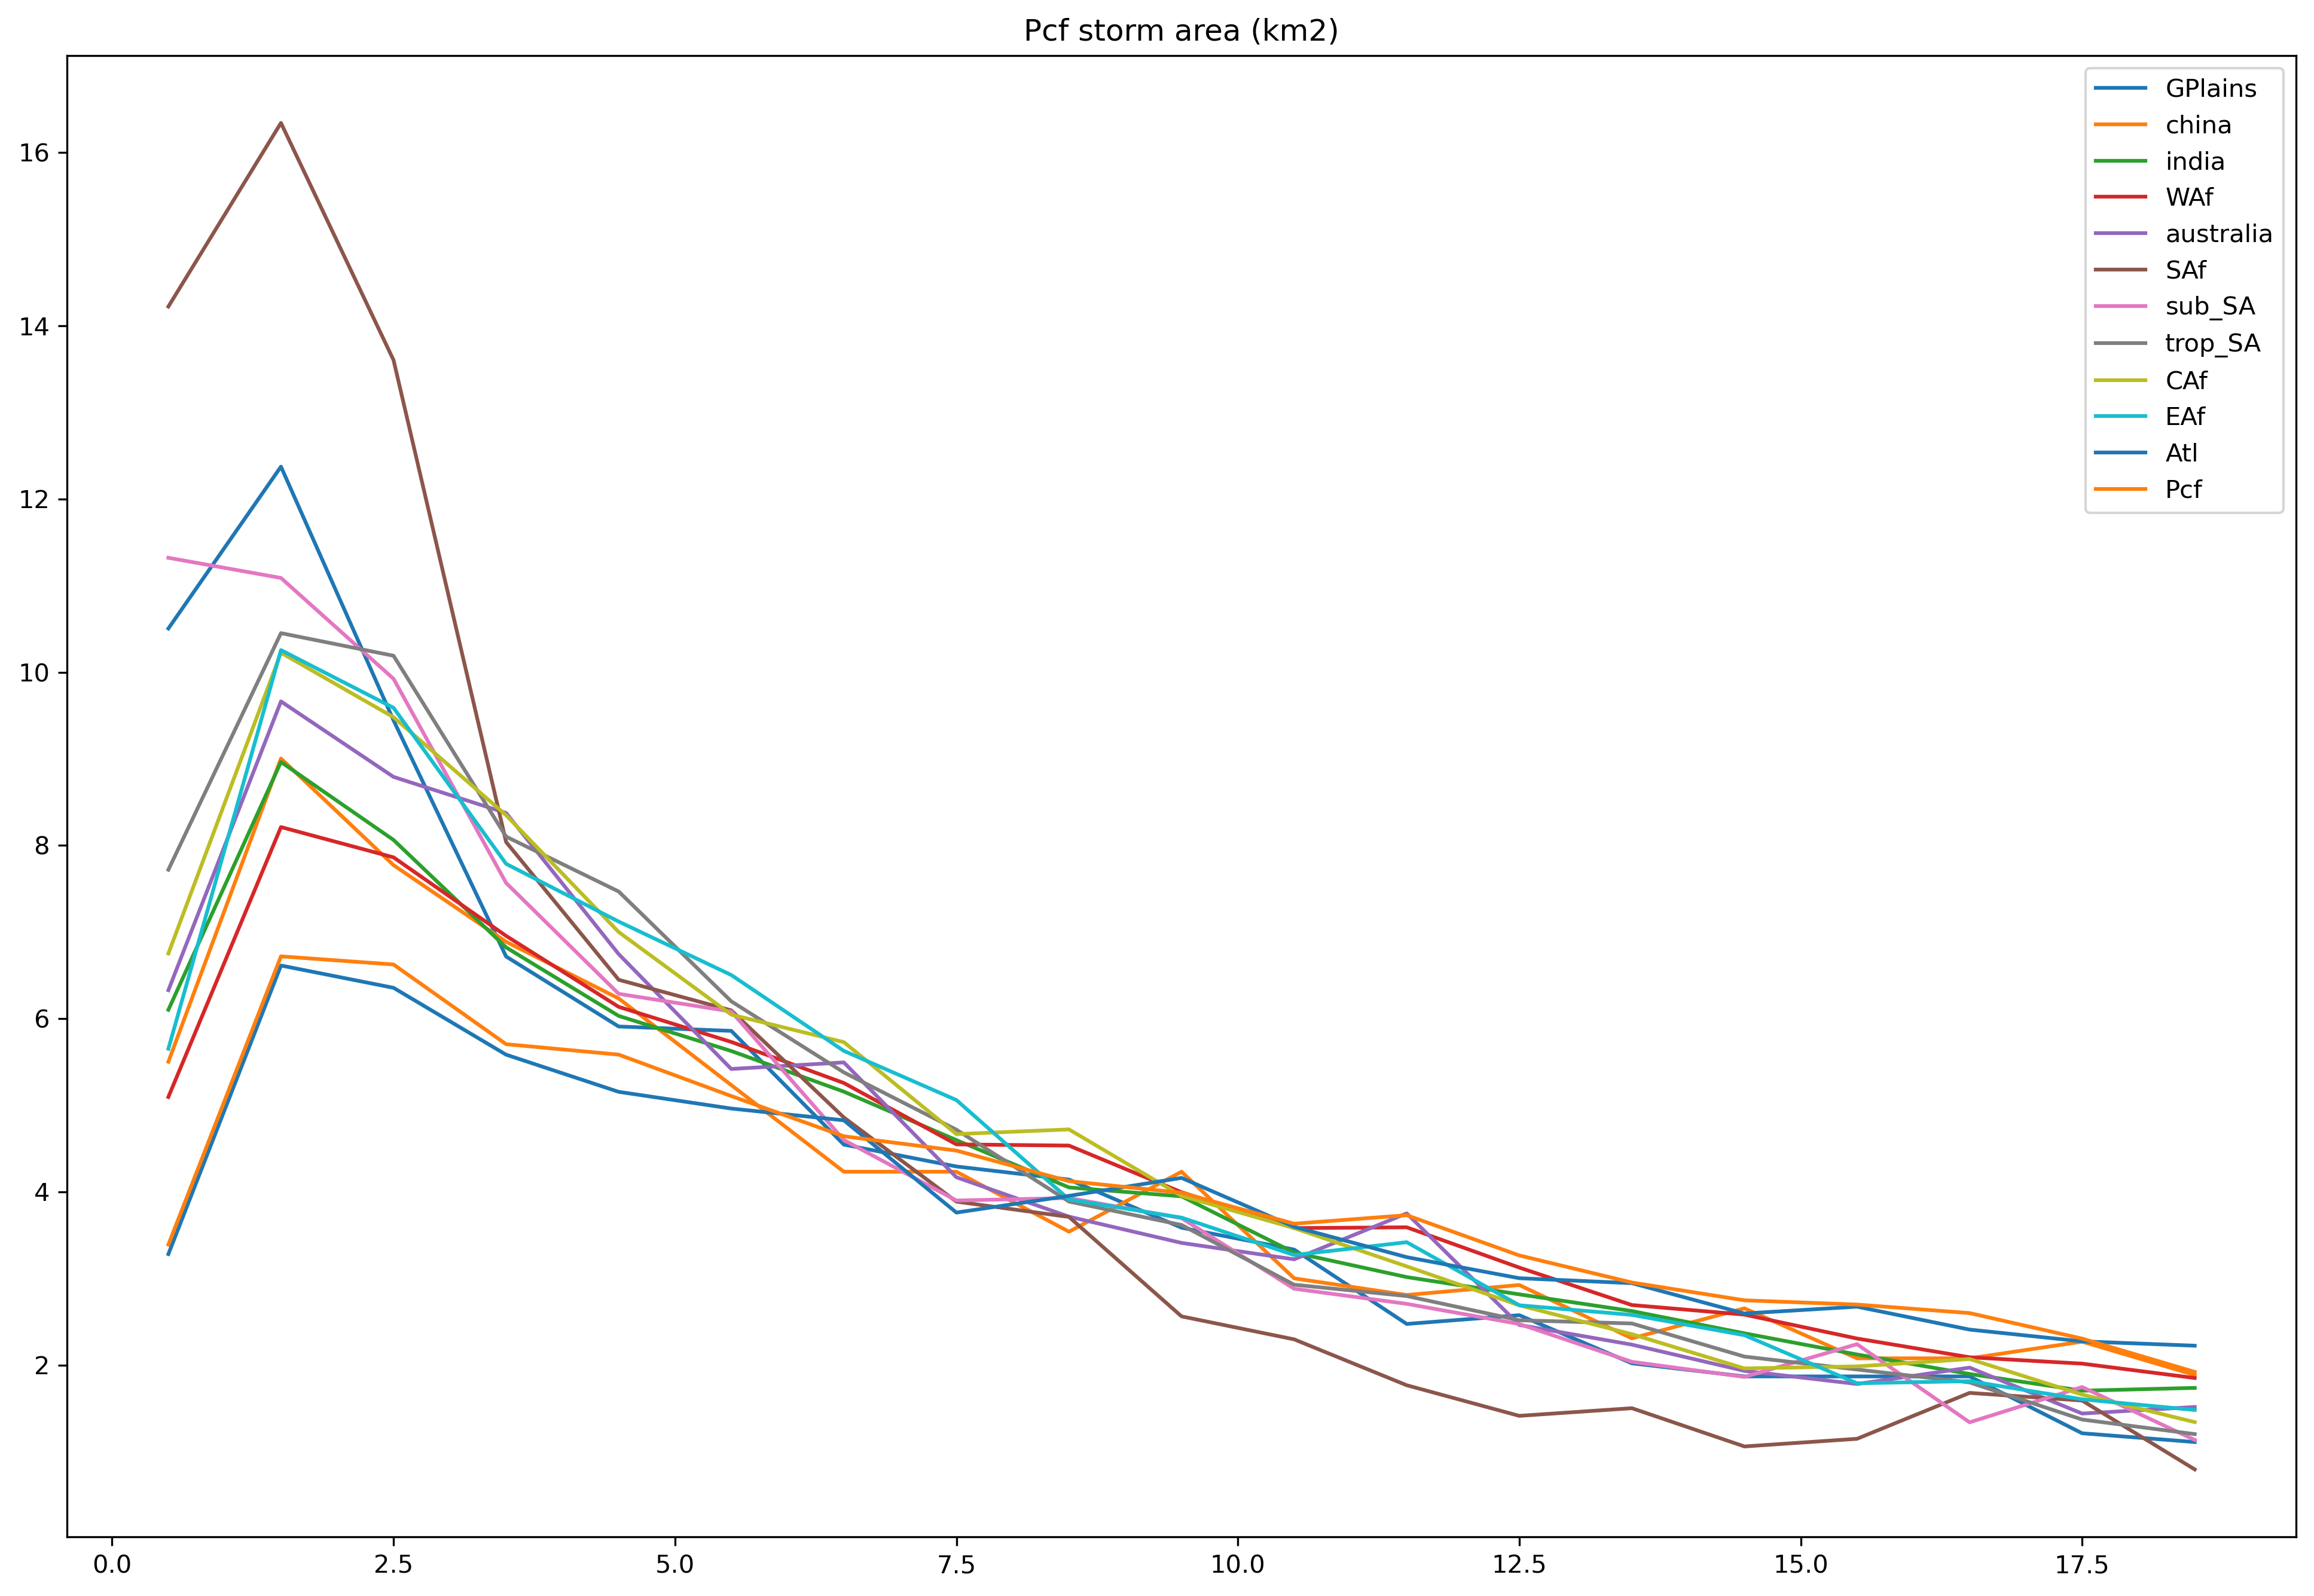

In [77]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['precipitation_max']>=10]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_area10mm']/pick['precipitation_area1mm']*100, bins=np.arange(0,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()